<a href="https://colab.research.google.com/github/MasArik09/Digital-Ad-Campaign-Performance-Analysis-ROAS-Prediction-using-Machine-Learning/blob/main/Digital_Ads_ML_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Ad Campaign Performance Analysis & ROAS Prediction
## Machine Learning | Data Mining Project

| Info | Detail |
|------|--------|
| **Dataset** | Global Ads Performance Dataset |
| **Ukuran** | 1.800 baris x 14 kolom |
| **Platform** | Google Ads, TikTok Ads, Meta Ads |
| **Periode** | Januari - Desember 2024 |
| **Target** | Prediksi ROAS & Segmentasi Kampanye |

---
### Struktur Notebook
1. Setup & Import Library
2. Load & Eksplorasi Data (EDA)
3. Visualisasi Distribusi & Korelasi
4. Feature Engineering & Preprocessing
5. Modeling: Regresi (Prediksi ROAS)
6. Evaluasi Model
7. Clustering Kampanye (Segmentasi)
8. Insight & Kesimpulan


## 1. Setup & Import Library

In [1]:
# Install library tambahan jika diperlukan
# !pip install lightgbm xgboost scikit-learn seaborn matplotlib pandas numpy --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("XGBoost tersedia!")
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost tidak tersedia, lewati model XGB.")

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print("Library berhasil diimport!")

XGBoost tersedia!
Library berhasil diimport!


## 2. Load & Eksplorasi Data (EDA)
### 2.1 Load Dataset

> **Catatan Google Colab:** Upload file CSV melalui panel Files, atau gunakan salah satu opsi di bawah.

In [3]:
# ── Opsi A: Upload langsung di Colab ──────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# ── Opsi B: Dari Google Drive ─────────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/global_ads_performance_dataset.csv')

# ── Opsi C: Jika file sudah ada di Colab ──────────────────────────────────
df = pd.read_csv('global_ads_performance_dataset.csv')

# Parse kolom tanggal
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset berhasil dimuat!")
print(f"  Ukuran : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"  Periode: {df['date'].min().date()} s/d {df['date'].max().date()}")

Dataset berhasil dimuat!
  Ukuran : 1,800 baris x 14 kolom
  Periode: 2024-01-01 s/d 2024-12-30


### 2.2 Melihat Struktur Data

In [4]:
df.head(10)

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39
5,2024-10-15,TikTok Ads,Search,Fintech,Canada,17666,724,0.0410,0.37,267.88,23,11.65,5220.85,19.49
6,2024-08-14,Meta Ads,Video,Fintech,USA,118252,3748,0.0317,0.42,1574.16,152,10.36,12838.56,8.16
7,2024-04-05,TikTok Ads,Search,EdTech,UAE,92939,5176,0.0557,0.66,3416.16,388,8.80,96298.69,28.19
8,2024-04-17,Meta Ads,Display,EdTech,Germany,30939,937,0.0303,0.59,552.83,63,8.78,16531.03,29.90
9,2024-11-13,Google Ads,Shopping,Fintech,USA,8748,362,0.0414,1.21,438.02,10,43.80,966.57,2.21


In [5]:
print("=" * 55)
print("INFORMASI KOLOM")
print("=" * 55)
df.info()
print()
print("=" * 55)
print("STATISTIK DESKRIPTIF")
print("=" * 55)
df.describe().round(2)

INFORMASI KOLOM
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1800 non-null   datetime64[ns]
 1   platform       1800 non-null   object        
 2   campaign_type  1800 non-null   object        
 3   industry       1800 non-null   object        
 4   country        1800 non-null   object        
 5   impressions    1800 non-null   int64         
 6   clicks         1800 non-null   int64         
 7   CTR            1800 non-null   float64       
 8   CPC            1800 non-null   float64       
 9   ad_spend       1800 non-null   float64       
 10  conversions    1800 non-null   int64         
 11  CPA            1800 non-null   float64       
 12  revenue        1800 non-null   float64       
 13  ROAS           1800 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(3), object(4)
me

,date,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
count,1800,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00
mean,2024-06-28 12:56:00,102919.02,3962.68,0.04,1.57,6171.53,181.56,46.61,30101.85,6.45
min,2024-01-01 00:00:00,5059.00,91.00,0.01,0.28,58.00,2.00,4.80,142.69,0.13
25%,2024-03-27 18:00:00,54948.00,1678.00,0.03,0.95,1966.59,59.00,20.20,7275.76,2.17
50%,2024-06-26 00:00:00,103653.00,3318.00,0.04,1.46,4393.86,130.00,33.38,18362.96,4.30
75%,2024-09-26 00:00:00,150470.25,5628.00,0.05,2.05,8455.83,252.25,56.81,38963.38,8.21
max,2024-12-30 00:00:00,199650.00,16660.00,0.10,3.95,38453.32,1151.00,335.86,295028.26,49.00
std,NaN,55740.90,2941.86,0.02,0.80,5777.00,171.42,41.19,34560.03,6.59


### 2.3 Cek Missing Values & Duplikat

In [6]:
print("Missing Values per Kolom:")
missing = df.isnull().sum()
print(missing.to_string())

print(f"\nJumlah Baris Duplikat: {df.duplicated().sum()}")
print("\nDataset bersih - tidak ada missing values maupun duplikat!")

Missing Values per Kolom:
date             0
platform         0
campaign_type    0
industry         0
country          0
impressions      0
clicks           0
CTR              0
CPC              0
ad_spend         0
conversions      0
CPA              0
revenue          0
ROAS             0

Jumlah Baris Duplikat: 0

Dataset bersih - tidak ada missing values maupun duplikat!


### 2.4 Distribusi Nilai Unik pada Kolom Kategorikal

In [7]:
cat_cols = ['platform', 'campaign_type', 'industry', 'country']
for col in cat_cols:
    counts = df[col].value_counts()
    print(f"\n{col.upper()} ({len(counts)} kategori):")
    for val, cnt in counts.items():
        pct = cnt / len(df) * 100
        bar = '#' * int(pct / 2)
        print(f"  {val:<20} {cnt:>4}  ({pct:.1f}%)  {bar}")


PLATFORM (3 kategori):
  Google Ads            720  (40.0%)  ####################
  Meta Ads              630  (35.0%)  #################
  TikTok Ads            450  (25.0%)  ############

CAMPAIGN_TYPE (4 kategori):
  Search                477  (26.5%)  #############
  Video                 456  (25.3%)  ############
  Shopping              447  (24.8%)  ############
  Display               420  (23.3%)  ###########

INDUSTRY (5 kategori):
  EdTech                372  (20.7%)  ##########
  SaaS                  370  (20.6%)  ##########
  Fintech               361  (20.1%)  ##########
  E-commerce            349  (19.4%)  #########
  Healthcare            348  (19.3%)  #########

COUNTRY (7 kategori):
  UK                    266  (14.8%)  #######
  USA                   266  (14.8%)  #######
  Canada                262  (14.6%)  #######
  India                 261  (14.5%)  #######
  UAE                   258  (14.3%)  #######
  Germany               255  (14.2%)  #######
  Australia

## 3. Visualisasi Distribusi & Korelasi
### 3.1 Distribusi Variabel Target (ROAS)

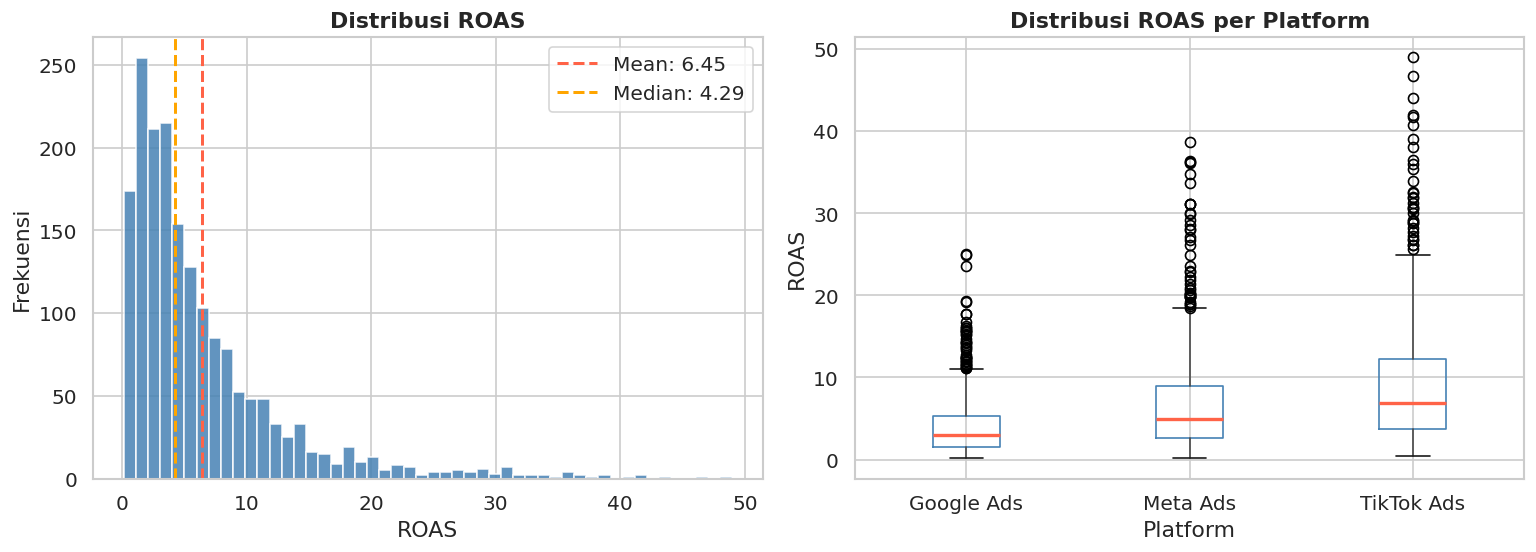

Skewness ROAS: 2.39  (right-skewed, distribusi miring ke kanan)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['ROAS'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['ROAS'].mean(), color='tomato', linestyle='--', linewidth=1.8,
                label=f'Mean: {df["ROAS"].mean():.2f}')
axes[0].axvline(df['ROAS'].median(), color='orange', linestyle='--', linewidth=1.8,
                label=f'Median: {df["ROAS"].median():.2f}')
axes[0].set_title('Distribusi ROAS', fontweight='bold')
axes[0].set_xlabel('ROAS')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

df.boxplot(column='ROAS', by='platform', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Distribusi ROAS per Platform', fontweight='bold')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('ROAS')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(f"Skewness ROAS: {df['ROAS'].skew():.2f}  (right-skewed, distribusi miring ke kanan)")

### 3.2 Rata-rata ROAS per Dimensi Bisnis

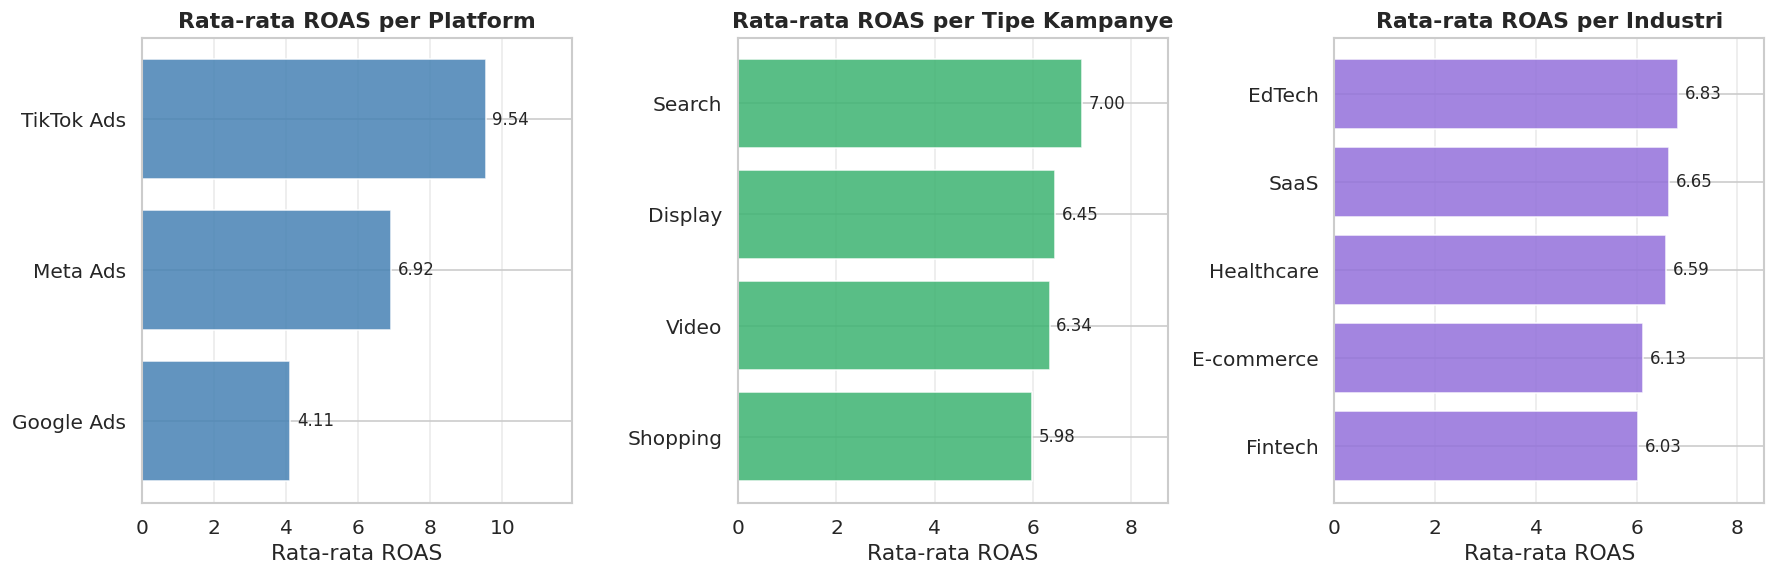

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
dims = [
    ('platform',      'Platform',      'steelblue'),
    ('campaign_type', 'Tipe Kampanye', 'mediumseagreen'),
    ('industry',      'Industri',      'mediumpurple'),
]
for ax, (col, label, color) in zip(axes, dims):
    means = df.groupby(col)['ROAS'].mean().sort_values(ascending=True)
    bars = ax.barh(means.index, means.values, color=color, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=10)
    ax.set_title(f'Rata-rata ROAS per {label}', fontweight='bold')
    ax.set_xlabel('Rata-rata ROAS')
    ax.set_xlim(0, means.max() * 1.25)
    ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

### 3.3 Heatmap Korelasi Antar Fitur Numerik

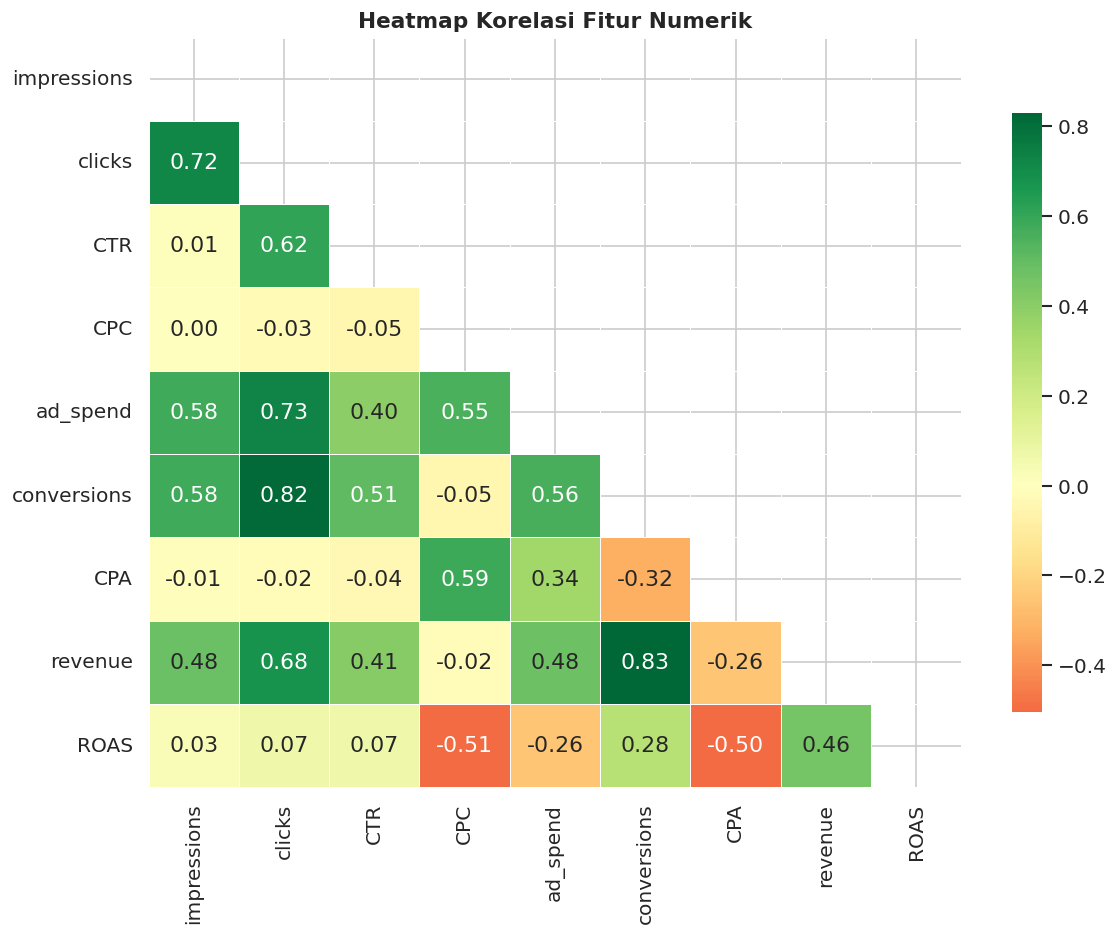


Korelasi tertinggi dengan ROAS:
  CPC             -0.505  negatif (-)
  CPA             -0.500  negatif (-)
  revenue          0.457  positif (+)
  conversions      0.276  positif (+)
  ad_spend        -0.255  negatif (-)
  CTR              0.071  positif (+)
  clicks           0.066  positif (+)
  impressions      0.030  positif (+)


In [10]:
numeric_cols = ['impressions', 'clicks', 'CTR', 'CPC', 'ad_spend',
                'conversions', 'CPA', 'revenue', 'ROAS']
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi Fitur Numerik', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\nKorelasi tertinggi dengan ROAS:")
roas_corr = corr['ROAS'].drop('ROAS').sort_values(key=abs, ascending=False)
for feat, val in roas_corr.items():
    direction = 'positif (+)' if val > 0 else 'negatif (-)'
    print(f"  {feat:<15} {val:>6.3f}  {direction}")

### 3.4 Scatter Plot: Fitur Paling Berkorelasi dengan ROAS

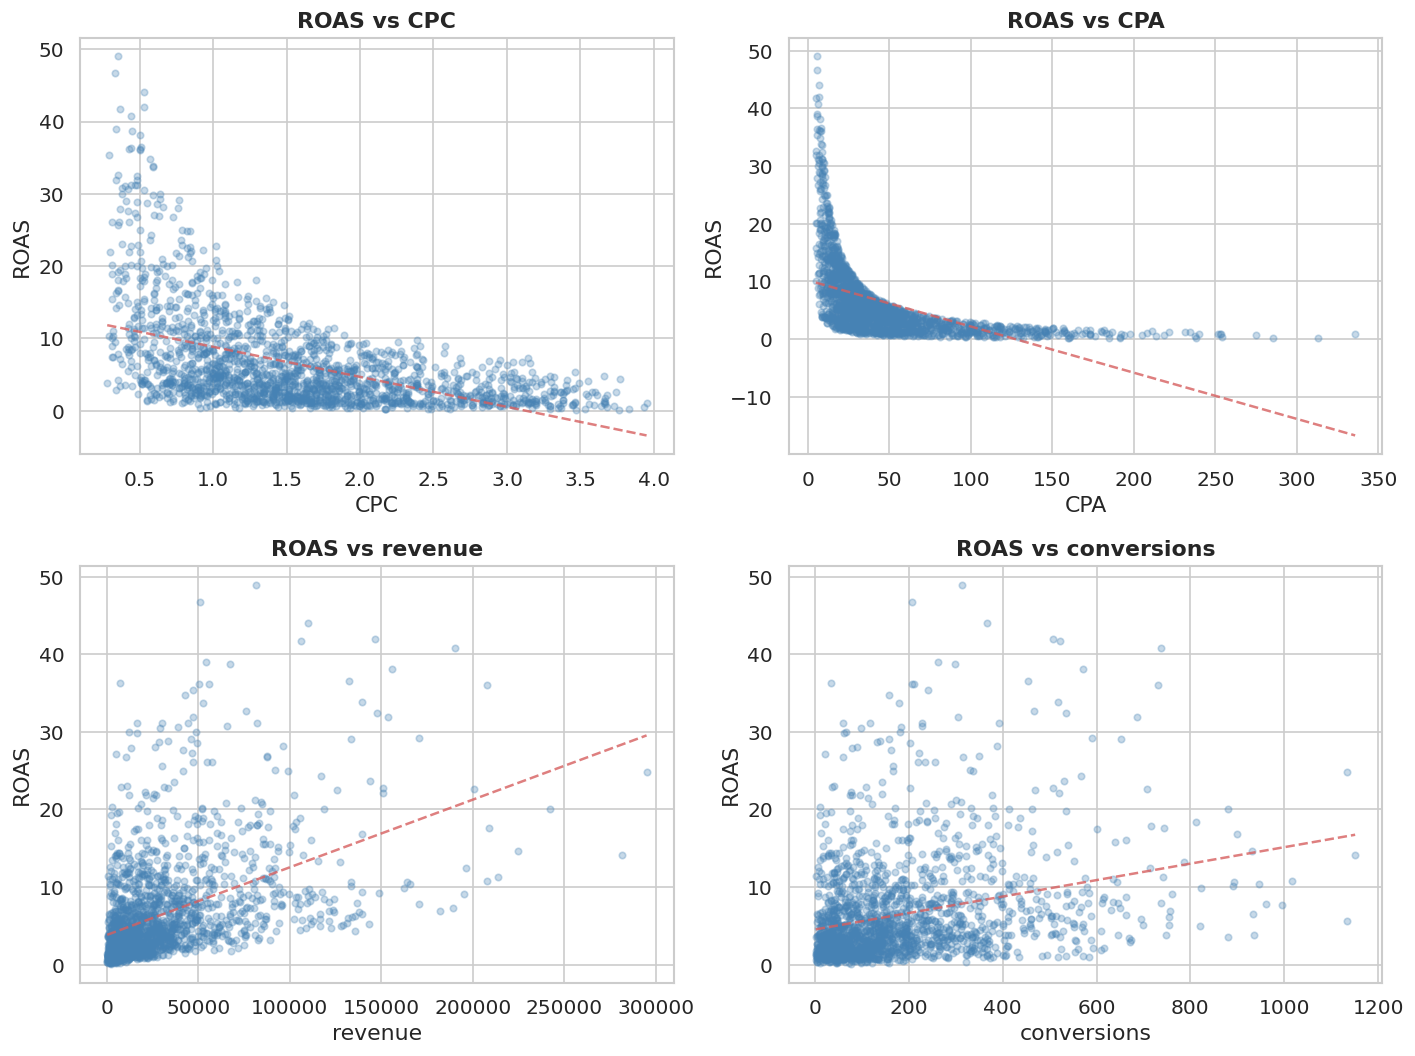

In [11]:
top_features = ['CPC', 'CPA', 'revenue', 'conversions']
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feat in zip(axes.flat, top_features):
    ax.scatter(df[feat], df['ROAS'], alpha=0.3, s=15, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('ROAS')
    ax.set_title(f'ROAS vs {feat}', fontweight='bold')
    z = np.polyfit(df[feat], df['ROAS'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, alpha=0.8)
plt.tight_layout()
plt.show()

### 3.5 Tren ROAS Bulanan (2024)

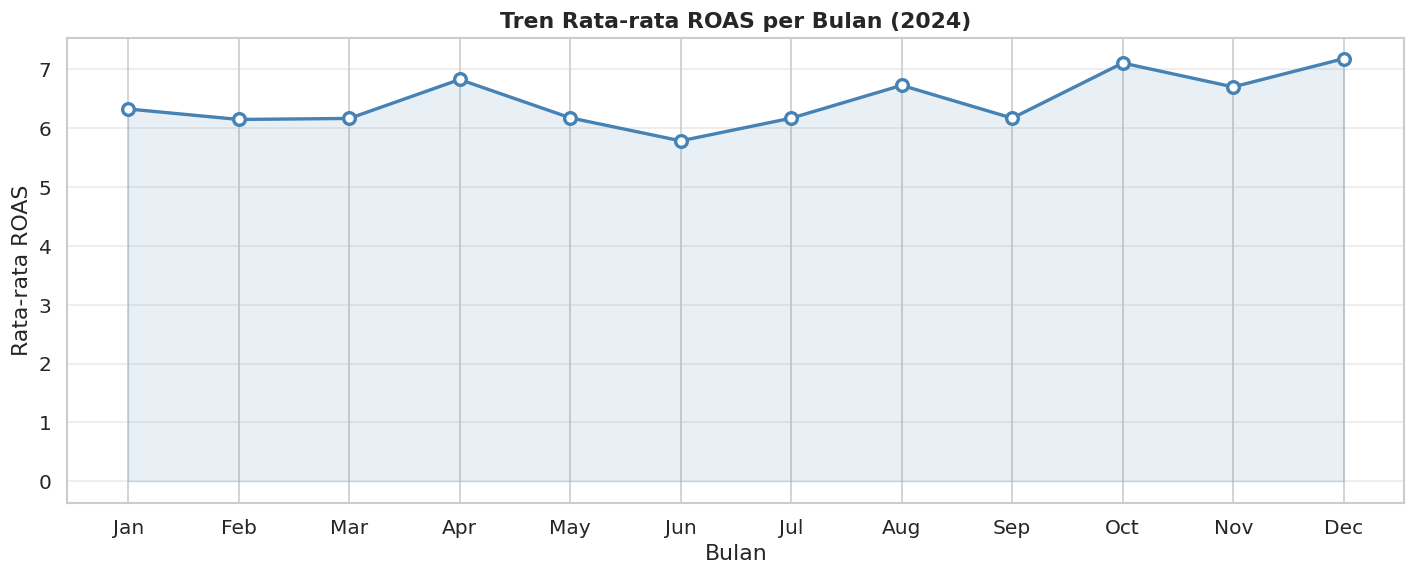

In [12]:
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
monthly = df.groupby(['month', 'month_name'])['ROAS'].mean().reset_index()
monthly = monthly.sort_values('month')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['month_name'], monthly['ROAS'], marker='o', linewidth=2,
        markersize=7, color='steelblue', markerfacecolor='white', markeredgewidth=2)
ax.fill_between(monthly['month_name'], monthly['ROAS'], alpha=0.12, color='steelblue')
ax.set_title('Tren Rata-rata ROAS per Bulan (2024)', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-rata ROAS')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### 3.6 ROAS per Negara

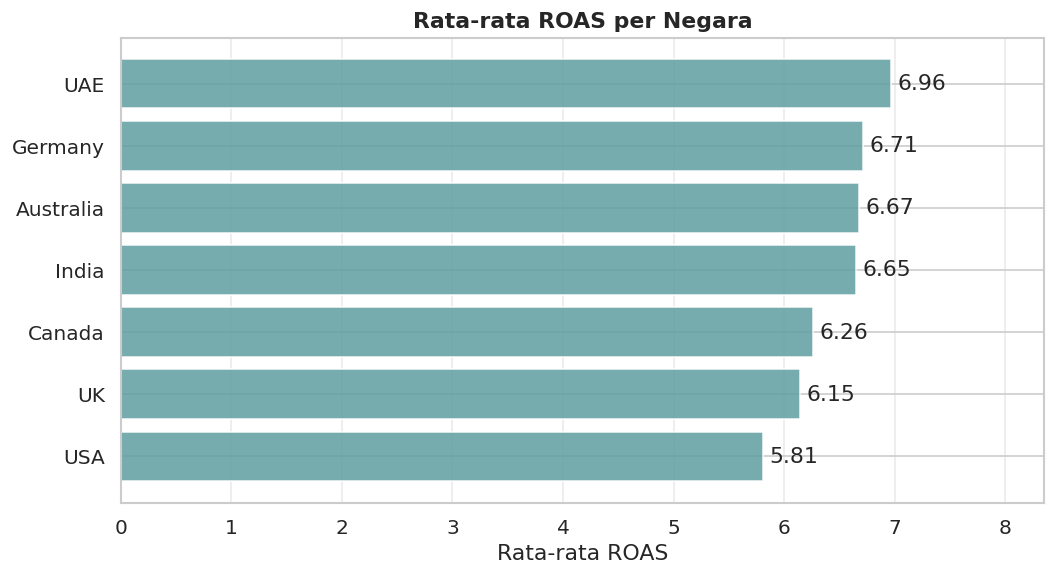

In [13]:
country_roas = df.groupby('country')['ROAS'].mean().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(country_roas.index, country_roas.values,
               color='cadetblue', alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=4)
ax.set_title('Rata-rata ROAS per Negara', fontweight='bold')
ax.set_xlabel('Rata-rata ROAS')
ax.set_xlim(0, country_roas.max() * 1.2)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing
### 4.1 Membuat Fitur Baru

In [14]:
df_ml = df.copy()

# Fitur rasio
df_ml['click_to_conv_rate'] = df_ml['conversions'] / (df_ml['clicks'] + 1)
df_ml['revenue_per_click']  = df_ml['revenue'] / (df_ml['clicks'] + 1)
df_ml['spend_efficiency']   = df_ml['revenue'] / (df_ml['ad_spend'] + 1)
df_ml['imp_to_click_rate']  = df_ml['clicks'] / (df_ml['impressions'] + 1)

# Fitur waktu
df_ml['quarter']     = df_ml['date'].dt.quarter
df_ml['day_of_week'] = df_ml['date'].dt.dayofweek
df_ml['is_weekend']  = (df_ml['day_of_week'] >= 5).astype(int)

print("Fitur baru berhasil dibuat:")
new_feats = ['click_to_conv_rate', 'revenue_per_click', 'spend_efficiency',
             'imp_to_click_rate', 'quarter', 'day_of_week', 'is_weekend']
for f in new_feats:
    print(f"  + {f}")

Fitur baru berhasil dibuat:
  + click_to_conv_rate
  + revenue_per_click
  + spend_efficiency
  + imp_to_click_rate
  + quarter
  + day_of_week
  + is_weekend


### 4.2 Encoding Variabel Kategorikal

In [15]:
cat_cols = ['platform', 'campaign_type', 'industry', 'country']
le_dict  = {}
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col])
    le_dict[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  {col}: {mapping}")
print("\nLabel Encoding selesai!")

  platform: {'Google Ads': np.int64(0), 'Meta Ads': np.int64(1), 'TikTok Ads': np.int64(2)}
  campaign_type: {'Display': np.int64(0), 'Search': np.int64(1), 'Shopping': np.int64(2), 'Video': np.int64(3)}
  industry: {'E-commerce': np.int64(0), 'EdTech': np.int64(1), 'Fintech': np.int64(2), 'Healthcare': np.int64(3), 'SaaS': np.int64(4)}
  country: {'Australia': np.int64(0), 'Canada': np.int64(1), 'Germany': np.int64(2), 'India': np.int64(3), 'UAE': np.int64(4), 'UK': np.int64(5), 'USA': np.int64(6)}

Label Encoding selesai!


### 4.3 Memilih Fitur & Split Data

In [16]:
feature_cols = [
    # Numerik original (tanpa revenue untuk menghindari data leakage)
    'impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA',
    # Kategorikal (encoded)
    'platform_enc', 'campaign_type_enc', 'industry_enc', 'country_enc',
    # Waktu
    'month', 'quarter', 'day_of_week', 'is_weekend',
    # Fitur turunan
    'click_to_conv_rate', 'revenue_per_click', 'imp_to_click_rate', 'spend_efficiency',
]

# Catatan: revenue di-exclude untuk menghindari data leakage
# karena ROAS = revenue / ad_spend

TARGET = 'ROAS'
X = df_ml[feature_cols]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Data berhasil dibagi:")
print(f"  Training  : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Testing   : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"  Jumlah fitur: {X_train.shape[1]}")

Data berhasil dibagi:
  Training  : 1,440 baris (80%)
  Testing   : 360 baris (20%)
  Jumlah fitur: 19


### 4.4 Normalisasi Fitur

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("StandardScaler diterapkan — mean=0, std=1 pada training set.")

StandardScaler diterapkan — mean=0, std=1 pada training set.


## 5. Modeling: Regresi untuk Prediksi ROAS

Membandingkan 4 model:

| Model | Deskripsi |
|-------|----------|
| **Linear Regression** | Baseline sederhana, mudah diinterpretasi |
| **Ridge Regression** | Linear + regularisasi L2, mencegah overfitting |
| **Random Forest** | Ensemble decision trees, kuat untuk data non-linear |
| **XGBoost** | Gradient boosting, umumnya terbaik untuk data tabular |

In [18]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Latih model dan kembalikan metrik evaluasi."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)

    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5,
                                 scoring='r2', n_jobs=-1)
    return {
        'Model'        : name,
        'RMSE'         : round(rmse, 4),
        'MAE'          : round(mae, 4),
        'R2_Test'      : round(r2, 4),
        'R2_CV_mean'   : round(cv_scores.mean(), 4),
        'R2_CV_std'    : round(cv_scores.std(), 4),
        '_model'       : model,
        '_y_pred'      : y_pred,
    }

results = []

print("Melatih Linear Regression...")
results.append(evaluate_model(
    'Linear Regression', LinearRegression(),
    X_train_scaled, y_train, X_test_scaled, y_test))

print("Melatih Ridge Regression...")
results.append(evaluate_model(
    'Ridge Regression', Ridge(alpha=1.0),
    X_train_scaled, y_train, X_test_scaled, y_test))

print("Melatih Random Forest...")
results.append(evaluate_model(
    'Random Forest',
    RandomForestRegressor(n_estimators=200, max_depth=12,
                          random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test))

if XGB_AVAILABLE:
    print("Melatih XGBoost...")
    results.append(evaluate_model(
        'XGBoost',
        xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=42, verbosity=0),
        X_train, y_train, X_test, y_test))

print("\nSemua model selesai dilatih!")

Melatih Linear Regression...
Melatih Ridge Regression...
Melatih Random Forest...
Melatih XGBoost...

Semua model selesai dilatih!


## 6. Evaluasi Model

In [19]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                           for r in results])
results_df = results_df.sort_values('R2_Test', ascending=False).reset_index(drop=True)
results_df.index += 1

print("=" * 65)
print("PERBANDINGAN PERFORMA MODEL")
print("=" * 65)
display(results_df)

best_model_name = results_df.iloc[0]['Model']
best_r2         = results_df.iloc[0]['R2_Test']
print(f"\nModel terbaik: {best_model_name} (R2 = {best_r2})")

PERBANDINGAN PERFORMA MODEL


,Model,RMSE,MAE,R2_Test,R2_CV_mean,R2_CV_std
1,Linear Regression,0.0089,0.0048,1.0000,1.0000,0.0000
2,Ridge Regression,0.0135,0.0077,1.0000,1.0000,0.0000
3,Random Forest,0.1676,0.0365,0.9995,0.9982,0.0023
4,XGBoost,0.5472,0.2220,0.9942,0.9924,0.0055



Model terbaik: Linear Regression (R2 = 1.0)


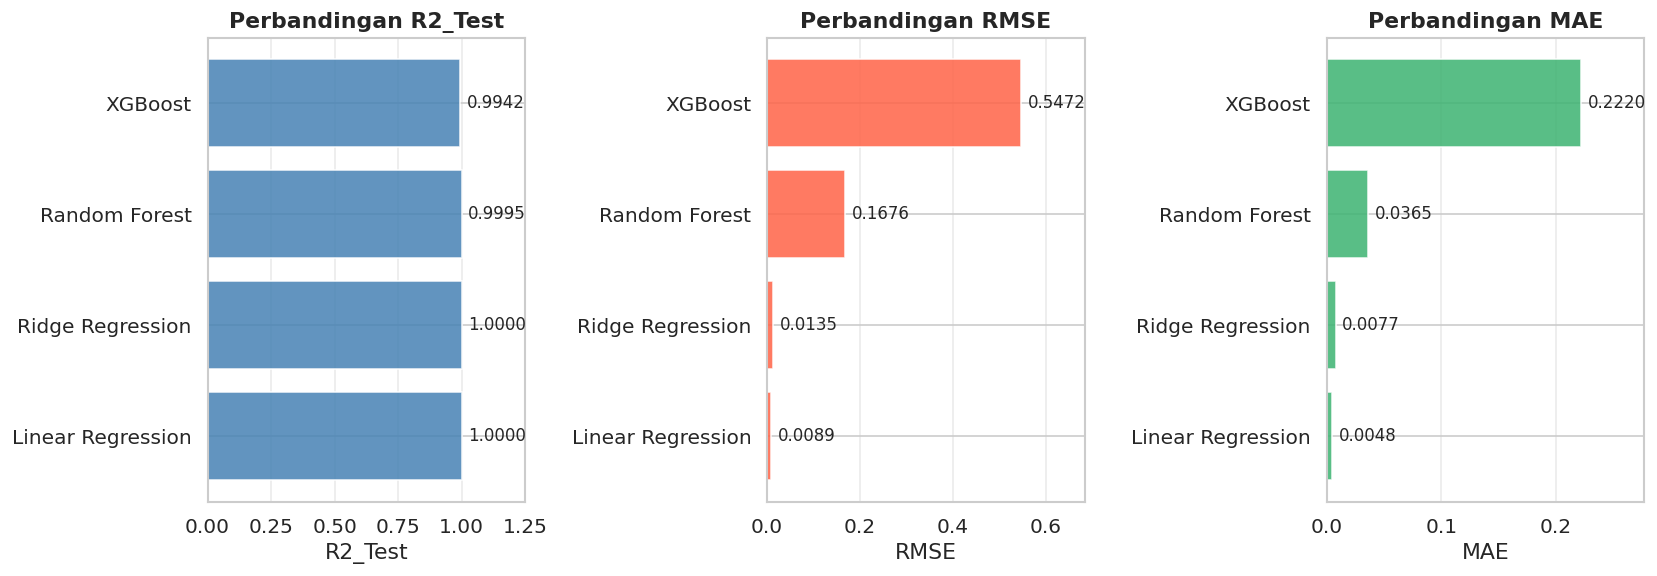

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['R2_Test', 'RMSE', 'MAE']
colors  = ['steelblue', 'tomato', 'mediumseagreen']
for ax, metric, color in zip(axes, metrics, colors):
    ascending = (metric != 'R2_Test')
    data = results_df.sort_values(metric, ascending=ascending)
    bars = ax.barh(data['Model'], data[metric], color=color, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
    ax.set_title(f'Perbandingan {metric}', fontweight='bold')
    ax.set_xlabel(metric)
    ax.set_xlim(0, data[metric].max() * 1.25)
    ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

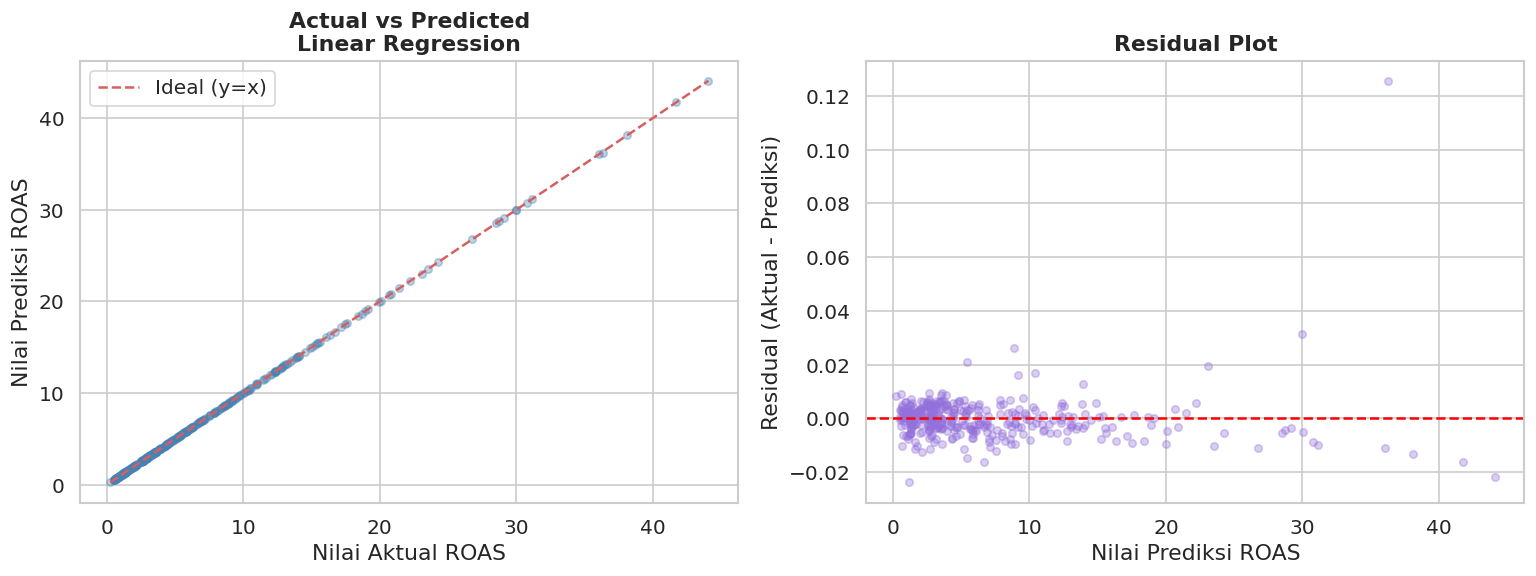

In [21]:
best_result = next(r for r in results if r['Model'] == best_model_name)
y_pred_best = best_result['_y_pred']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.35, s=20, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()),
        max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal (y=x)')
ax.set_xlabel('Nilai Aktual ROAS')
ax.set_ylabel('Nilai Prediksi ROAS')
ax.set_title(f'Actual vs Predicted\n{best_model_name}', fontweight='bold')
ax.legend()

residuals = y_test - y_pred_best
ax2 = axes[1]
ax2.scatter(y_pred_best, residuals, alpha=0.35, s=20, color='mediumpurple')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Nilai Prediksi ROAS')
ax2.set_ylabel('Residual (Aktual - Prediksi)')
ax2.set_title('Residual Plot', fontweight='bold')
plt.tight_layout()
plt.show()

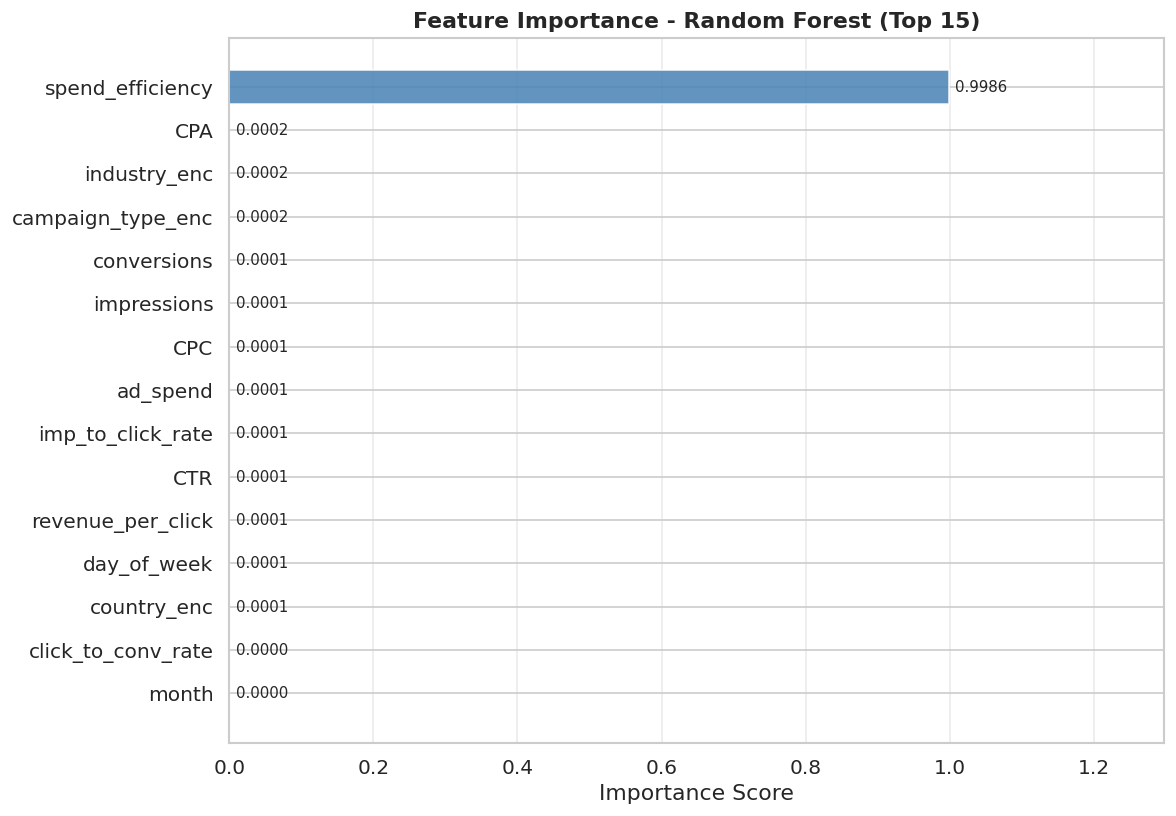

In [22]:
rf_result = next((r for r in results if 'Random Forest' in r['Model']), None)
if rf_result:
    rf_model     = rf_result['_model']
    importances  = pd.Series(rf_model.feature_importances_, index=feature_cols)
    importances  = importances.sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(importances.index, importances.values,
                   color='steelblue', alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
    ax.set_title('Feature Importance - Random Forest (Top 15)', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.set_xlim(0, importances.max() * 1.3)
    ax.grid(axis='x', alpha=0.4)
    plt.tight_layout()
    plt.show()

## 7. Clustering Kampanye (Segmentasi)

Menggunakan **K-Means Clustering** untuk menemukan segmen kampanye berdasarkan pola performa. Pertanyaan yang dijawab: *Tipe kampanye mana yang paling efisien?*

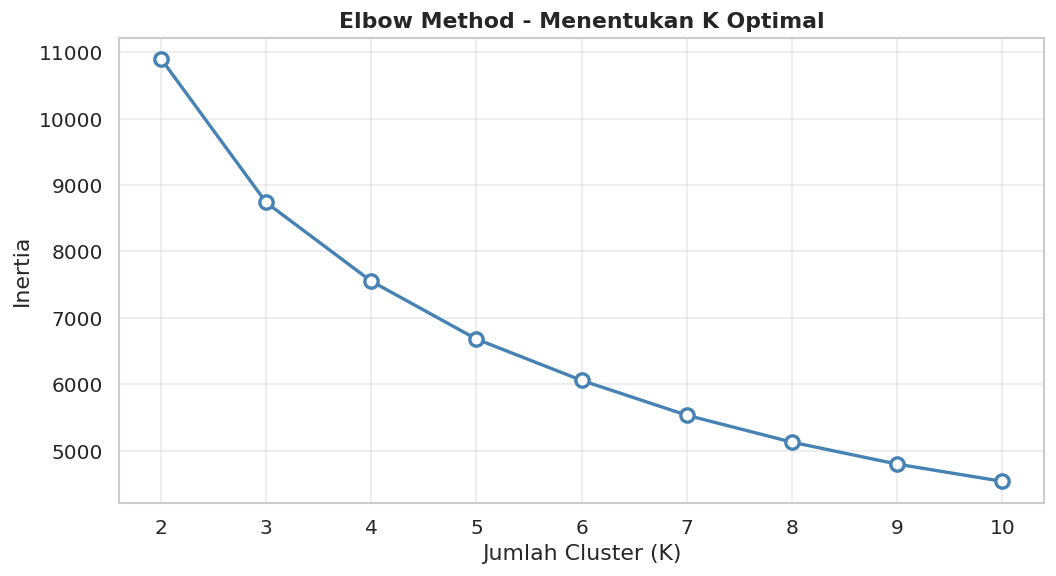

Pilih K di titik siku - di mana penurunan inertia mulai melambat.


In [23]:
cluster_features = ['CTR', 'CPC', 'CPA', 'ROAS', 'conversions',
                    'ad_spend', 'revenue', 'click_to_conv_rate']

X_cluster   = df_ml[cluster_features].copy()
scaler_cl   = StandardScaler()
X_scaled_cl = scaler_cl.fit_transform(X_cluster)

inertias = []
k_range  = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_cl)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), inertias, marker='o', linewidth=2, color='steelblue',
        markerfacecolor='white', markeredgewidth=2, markersize=8)
ax.set_title('Elbow Method - Menentukan K Optimal', fontweight='bold')
ax.set_xlabel('Jumlah Cluster (K)')
ax.set_ylabel('Inertia')
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()
print("Pilih K di titik siku - di mana penurunan inertia mulai melambat.")

In [24]:
OPTIMAL_K = 4   # Sesuaikan setelah melihat elbow chart di atas

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_ml['cluster'] = km_final.fit_predict(X_scaled_cl)

print(f"K-Means selesai dengan K={OPTIMAL_K}")
print("\nDistribusi per cluster:")
print(df_ml['cluster'].value_counts().sort_index())

K-Means selesai dengan K=4

Distribusi per cluster:
cluster
0    322
1    985
2    251
3    242
Name: count, dtype: int64


Variansi yang dijelaskan PCA: PC1=39.1%, PC2=30.3%
Total: 69.4%


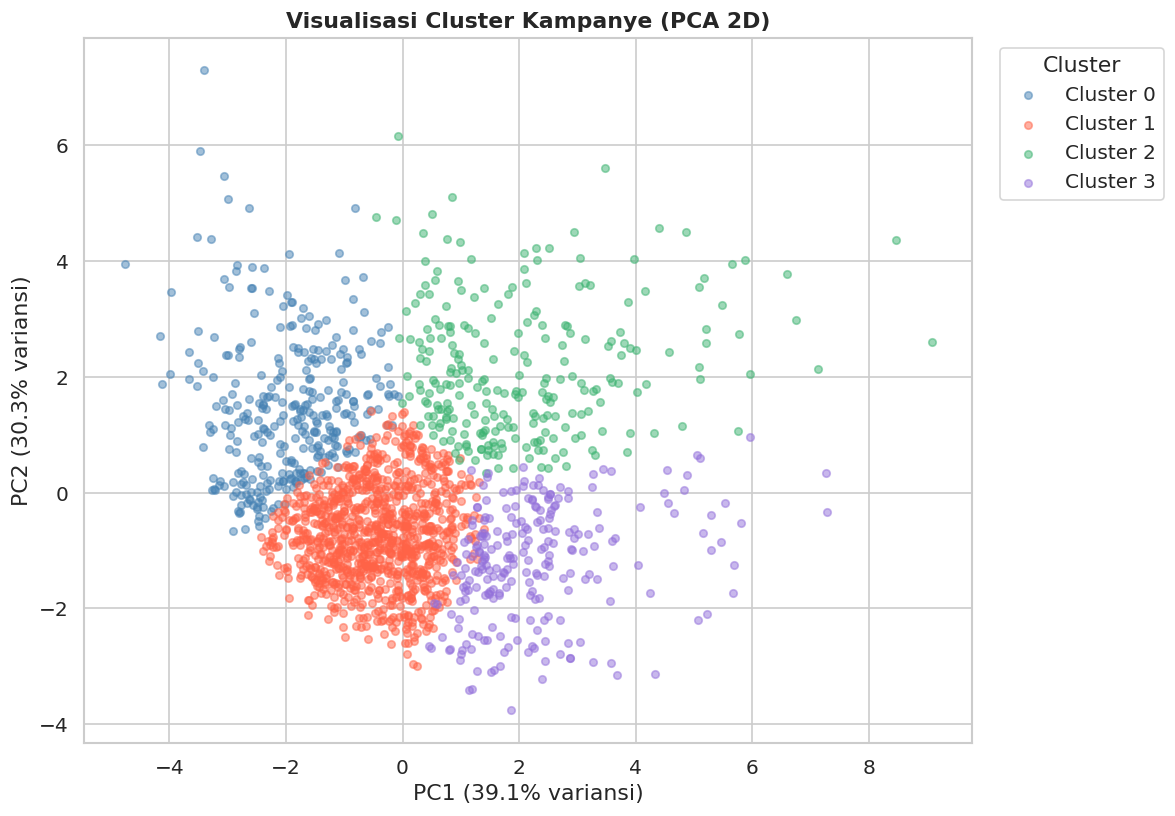

In [25]:
pca = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_scaled_cl)
explained = pca.explained_variance_ratio_

print(f"Variansi yang dijelaskan PCA: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}")
print(f"Total: {sum(explained):.1%}")

palette = ['steelblue', 'tomato', 'mediumseagreen', 'mediumpurple',
           'darkorange', 'crimson', 'teal']
fig, ax = plt.subplots(figsize=(10, 7))
for c in range(OPTIMAL_K):
    mask = df_ml['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               alpha=0.5, s=20, color=palette[c], label=f'Cluster {c}')
ax.set_title('Visualisasi Cluster Kampanye (PCA 2D)', fontweight='bold')
ax.set_xlabel(f'PC1 ({explained[0]:.1%} variansi)')
ax.set_ylabel(f'PC2 ({explained[1]:.1%} variansi)')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
cluster_profile = df_ml.groupby('cluster')[cluster_features].mean().round(2)
cluster_profile.index = [f'Cluster {i}' for i in cluster_profile.index]
print("=" * 70)
print("PROFIL RATA-RATA PER CLUSTER")
print("=" * 70)
display(cluster_profile)

PROFIL RATA-RATA PER CLUSTER


,CTR,CPC,CPA,ROAS,conversions,ad_spend,revenue,click_to_conv_rate
Cluster 0,0.04,2.36,116.14,1.55,85.38,8908.67,13585.17,0.02
Cluster 1,0.03,1.40,34.52,5.28,113.14,3553.30,16053.90,0.05
Cluster 2,0.06,2.02,37.91,5.57,459.86,15416.12,78398.00,0.06
Cluster 3,0.04,0.77,12.34,18.64,299.40,3597.98,59164.94,0.06


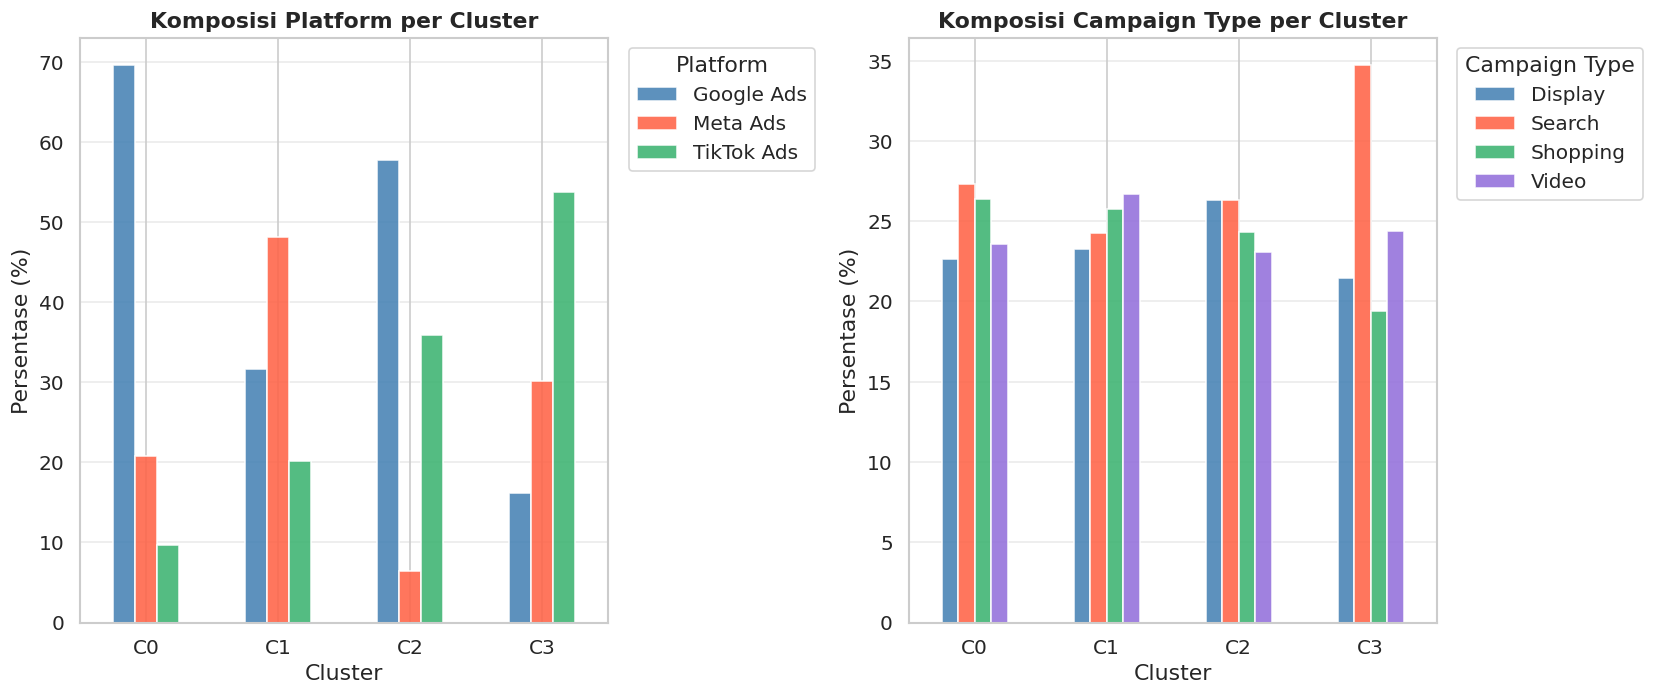

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col in zip(axes, ['platform', 'campaign_type']):
    ct = pd.crosstab(df_ml['cluster'], df_ml[col], normalize='index') * 100
    ct.index = [f'C{i}' for i in ct.index]
    ct.plot(kind='bar', ax=ax, color=palette[:len(ct.columns)],
            edgecolor='white', alpha=0.88)
    ax.set_title(f'Komposisi {col.replace("_"," ").title()} per Cluster', fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Persentase (%)')
    ax.legend(title=col.replace('_', ' ').title(),
              bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Insight & Kesimpulan Bisnis
### 8.1 Ringkasan Temuan

In [28]:
print("=" * 65)
print("RINGKASAN INSIGHT")
print("=" * 65)

best_platform     = df.groupby('platform')['ROAS'].mean().idxmax()
best_platform_v   = df.groupby('platform')['ROAS'].mean().max()
best_industry     = df.groupby('industry')['ROAS'].mean().idxmax()
best_industry_v   = df.groupby('industry')['ROAS'].mean().max()
best_camp         = df.groupby('campaign_type')['ROAS'].mean().idxmax()
best_camp_v       = df.groupby('campaign_type')['ROAS'].mean().max()
best_country      = df.groupby('country')['ROAS'].mean().idxmax()
best_country_v    = df.groupby('country')['ROAS'].mean().max()

print(f"\nPlatform terbaik  : {best_platform} (ROAS rata-rata: {best_platform_v:.2f})")
print(f"Industri terbaik  : {best_industry} (ROAS rata-rata: {best_industry_v:.2f})")
print(f"Tipe kampanye     : {best_camp} (ROAS rata-rata: {best_camp_v:.2f})")
print(f"Negara terbaik    : {best_country} (ROAS rata-rata: {best_country_v:.2f})")
print(f"\nModel ML terbaik  : {best_model_name}")
print(f"R2 Score          : {best_r2:.4f}")
print(f"Interpretasi      : model menjelaskan {best_r2*100:.1f}% variansi ROAS")

print("\n" + "=" * 65)
print("REKOMENDASI STRATEGIS")
print("=" * 65)
rekomendasi = [
    f"1. ALOKASI BUDGET    -> Prioritaskan {best_platform} karena ROAS tertinggi.",
    f"2. TARGETING INDUSTRI -> Fokus pada segmen {best_industry} untuk efisiensi optimal.",
    f"3. TIPE KAMPANYE     -> Optimalkan {best_camp} ads untuk return terbaik.",
     "4. SEGMENTASI        -> Gunakan profil cluster untuk scale-up kampanye high-performer.",
    f"5. PREDIKSI ROAS     -> Deploy model {best_model_name} sebelum budget dihabiskan.",
]
for r in rekomendasi:
    print(f"  {r}")

RINGKASAN INSIGHT

Platform terbaik  : TikTok Ads (ROAS rata-rata: 9.54)
Industri terbaik  : EdTech (ROAS rata-rata: 6.83)
Tipe kampanye     : Search (ROAS rata-rata: 7.00)
Negara terbaik    : UAE (ROAS rata-rata: 6.96)

Model ML terbaik  : Linear Regression
R2 Score          : 1.0000
Interpretasi      : model menjelaskan 100.0% variansi ROAS

REKOMENDASI STRATEGIS
  1. ALOKASI BUDGET    -> Prioritaskan TikTok Ads karena ROAS tertinggi.
  2. TARGETING INDUSTRI -> Fokus pada segmen EdTech untuk efisiensi optimal.
  3. TIPE KAMPANYE     -> Optimalkan Search ads untuk return terbaik.
  4. SEGMENTASI        -> Gunakan profil cluster untuk scale-up kampanye high-performer.
  5. PREDIKSI ROAS     -> Deploy model Linear Regression sebelum budget dihabiskan.


### 8.2 Kesimpulan Metodologi

| Tahap | Metode | Hasil |
|-------|--------|-------|
| EDA | Pandas, Matplotlib, Seaborn | Pola distribusi & korelasi |
| Preprocessing | Label Encoding, StandardScaler | Data siap ML |
| Feature Engineering | Rasio baru, fitur waktu | Kualitas fitur meningkat |
| Regresi | Linear, Ridge, Random Forest, XGBoost | Prediksi ROAS |
| Clustering | K-Means + PCA | Segmentasi kampanye |

---
### Referensi
- Scikit-learn: https://scikit-learn.org
- XGBoost: https://xgboost.readthedocs.io
- Seaborn: https://seaborn.pydata.org

> Dataset: Global Ads Performance Dataset | Project: ML & Data Mining
